# CNN Multi Dim Analysis

### Imports, datasets and types

In [25]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch

from pathlib import Path
from torch import Tensor, nn

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder
from molearn.models.CNN_autoencoder import ToND, FromND
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *

RANDOM_STATE = 42

device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
atoms: list[str] = ["N", "CA", "C", "O", 'CB']

mean: float = json.load(open("../data/data_statistics_full.json"))["mean"]
std: float = json.load(open("../data/data_statistics_full.json"))["std"]

data_closed = PDBData(
    filename=["../data/full_murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ : Tensor = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["../data/full_murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_open.prepare_dataset(mean=mean, std=std)

data_both = PDBData(
    filename=["../data/full_murd_both.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full_murd_test.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_:Tensor = data_test.prepare_dataset(mean=mean, std=std)


PlotData = list[tuple[str, ...]]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1600, 2145, 3])


### Loading results

In [27]:
BASE_PATH: str = r"../results/11-feb-2026-latent-dim-physics"

TRIPLICATES: list[int] = [1, 2, 3]
TARGET_VARS: list[int] = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

log_dfs: dict[int, dict[int, pd.DataFrame]]
min_valid_losses: dict[int, dict[int, float]]
min_valid_mse_losses: dict[int, dict[int, float]]
models: dict[int, dict[int, AutoEncoder]]
MAs: dict[int, dict[int, MolearnAnalysis]]

log_dfs, min_valid_losses, min_valid_mse_losses, models, MAs = (
    {t : {} for t in TRIPLICATES} for _ in range(5))


for t in TRIPLICATES:
    for n in TARGET_VARS:
        
        log_dfs[t][n] = pd.read_csv(Path(f"{BASE_PATH}/{t}/{n}/log.dat"))
        best_epoch: int = log_dfs[t][n]['valid_loss'].idxmin()  # type: ignore[assignment]
        min_valid_losses[t][n] = min(log_dfs[t][n].valid_loss)
        min_valid_mse_losses[t][n] = min(log_dfs[t][n].valid_mse_loss)

        checkpoint_path: Path = Path(f"{BASE_PATH}/{t}/{n}/checkpoint_converged.ckpt")
        checkpoint: dict = torch.load(checkpoint_path, map_location=device, weights_only=False)

        model: AutoEncoder = AutoEncoder(n_atoms=data_open.dataset.shape[1], latent_dim=n)
        model.load_state_dict(checkpoint['model_state_dict'])

        models[t][n] = model

        MA: MolearnAnalysis = MolearnAnalysis() 
        MA.batch_size = 16
        MA.processes = 4

        MA.set_dataset(data=data_open, key="train_open")
        MA.set_dataset(data=data_closed, key="train_closed")
        MA.set_dataset(data=data_both, key="train_both")
        MA.set_dataset(data=data_test, key="test_trans")

        MA.set_network(models[t][n])

        MAs[t][n] = MA

Computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([4000, 2145, 3])


### Model architecture and shapes

In [ ]:
def print_encoder_shapes(model: AutoEncoder, n_atoms: int) -> None:
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x: Tensor = torch.randn(1, n_atoms, 3)
    
    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")
    
    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed: Tensor = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal latent shape: {x.shape}")

# Test with your model

LATENT_DIM: int = 7
RUN: int = 1

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={LATENT_DIM}")
print("=" * 60)
print_encoder_shapes(models[RUN][LATENT_DIM], n_atoms=data_open.dataset.shape[1])

print(data_both.dataset.shape)

ENCODER FORWARD PASS - latent_dim=7
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 7])

Final latent shape: torch.Size([1, 7])
torch.Size([4000, 2145, 3])


In [ ]:
def print_decoder_shapes(model: AutoEncoder, latent_dim: int) -> Tensor:
    """Print the shape at each stage of the decoder"""
    # Create dummy latent input: (batch=1, latent_dim)
    x: Tensor = torch.randn(1, latent_dim)
    print(f"Input latent shape: {x.shape}")
    
    for i, m in enumerate(model.decoder):
        x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal output shape: {x.shape}")
    return x

# Test with your model
LATENT_DIM: int = 7
RUN: int = 1

print("=" * 60)
print(f"DECODER FORWARD PASS - latent_dim={LATENT_DIM}")
print("=" * 60)
decoded: Tensor = print_decoder_shapes(models[RUN][LATENT_DIM], LATENT_DIM)
print(f"\nExpected atoms: {data_open.dataset.shape[1]}")
print(f"Decoder output atoms: {decoded.shape[2]}")
print(f"Difference: {decoded.shape[2] - data_open.dataset.shape[1]} atoms discarded")

DECODER FORWARD PASS - latent_dim=7
Input latent shape: torch.Size([1, 7])
Layer 0 (FromND): torch.Size([1, 1, 17])
Layer 1 (ConvTranspose1d): torch.Size([1, 243, 34])
Layer 4 (ConvTranspose1d): torch.Size([1, 162, 68])
Layer 7 (ConvTranspose1d): torch.Size([1, 108, 136])
Layer 10 (ConvTranspose1d): torch.Size([1, 72, 272])
Layer 13 (ConvTranspose1d): torch.Size([1, 48, 544])
Layer 16 (ConvTranspose1d): torch.Size([1, 32, 1088])
Layer 19 (ConvTranspose1d): torch.Size([1, 3, 2176])

Final output shape: torch.Size([1, 3, 2176])

Expected atoms: 2145
Decoder output atoms: 2176
Difference: 31 atoms discarded


### MSE Plots 

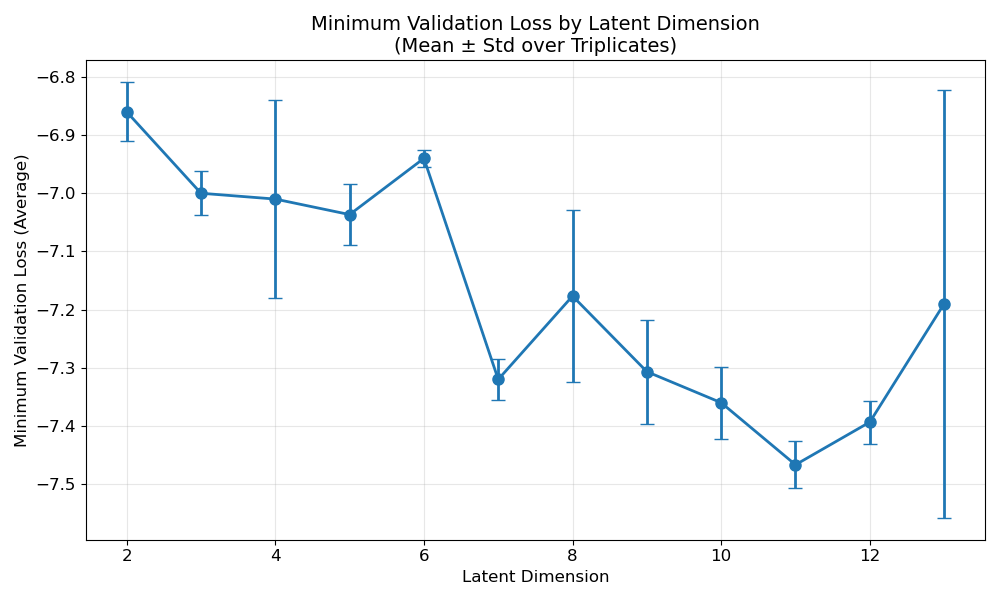

In [31]:
# Plot line graph of minimum validation losses (averaged over triplicates)

avg_valid_losses: dict[int, float] = {}
std_valid_losses: dict[int, float] = {}

for n in TARGET_VARS:
    losses: list[float] = [min_valid_losses[t][n] for t in TRIPLICATES]
    avg_valid_losses[n] = float(np.mean(losses))
    std_valid_losses[n] = float(np.std(losses))

plt.figure(figsize=(10, 6))
plt.errorbar(list(avg_valid_losses.keys()), list(avg_valid_losses.values()), 
             yerr=list(std_valid_losses.values()), marker='o', linewidth=2, markersize=8, capsize=5)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss (Average)', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension\n(Mean ± Std over Triplicates)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model plots

#### RMSD Hist plot

encoding train_open: 125it [00:00, 316.08it/s]
Decoding train_open: 125it [00:00, 182.23it/s]
encoding train_closed: 125it [00:00, 279.87it/s]
Decoding train_closed: 125it [00:00, 163.09it/s]
encoding test_trans: 100it [00:00, 275.47it/s]
Decoding test_trans: 100it [00:00, 162.15it/s]
encoding train_both: 250it [00:00, 266.12it/s]
Decoding train_both: 250it [00:01, 154.77it/s]


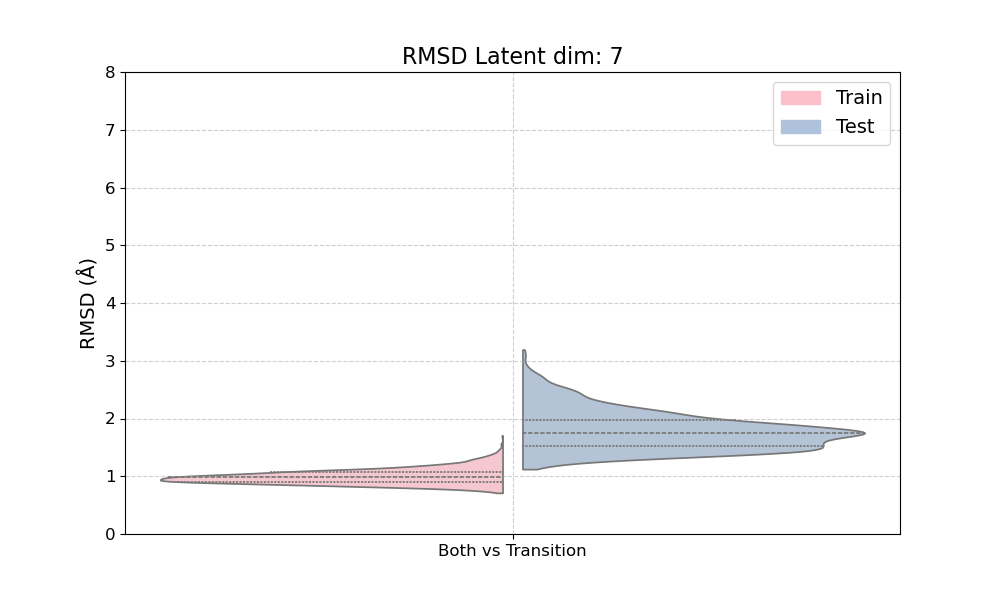

In [ ]:
from molearn.analysis.plot import plot_rmsd_hist

RUN: int = 1
TARGET_VARS: list[int] = [7]

for var in TARGET_VARS:
    rmsd_train_open:np.ndarray = MAs[RUN][var].get_error('train_open')
    rmsd_train_closed:np.ndarray = MAs[RUN][var].get_error('train_closed')
    rmsd_test_trans:np.ndarray = MAs[RUN][var].get_error('test_trans')

    rmsd_plot_data: PlotData = [
        ("train_both", "test_trans", "Both vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[RUN][var],
        plot_data=rmsd_plot_data,
        dpi=150,
        var=var,
    )

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=2


encoding train_open: 125it [00:01, 94.80it/s] 
Decoding train_open: 125it [00:03, 36.86it/s]
encoding train_closed: 125it [00:01, 76.55it/s] 
Decoding train_closed: 125it [00:01, 116.50it/s]
encoding test_trans: 13it [00:00, 285.63it/s]
Decoding test_trans: 13it [00:00, 32.68it/s]


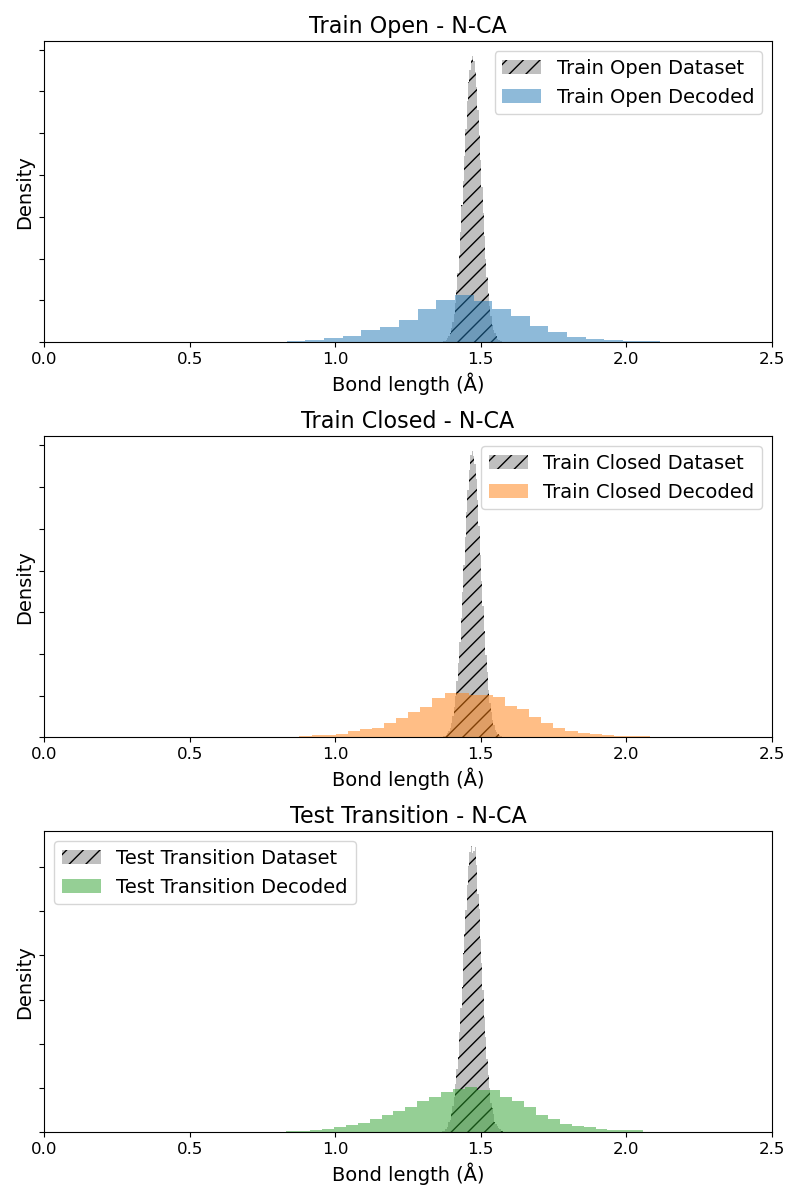

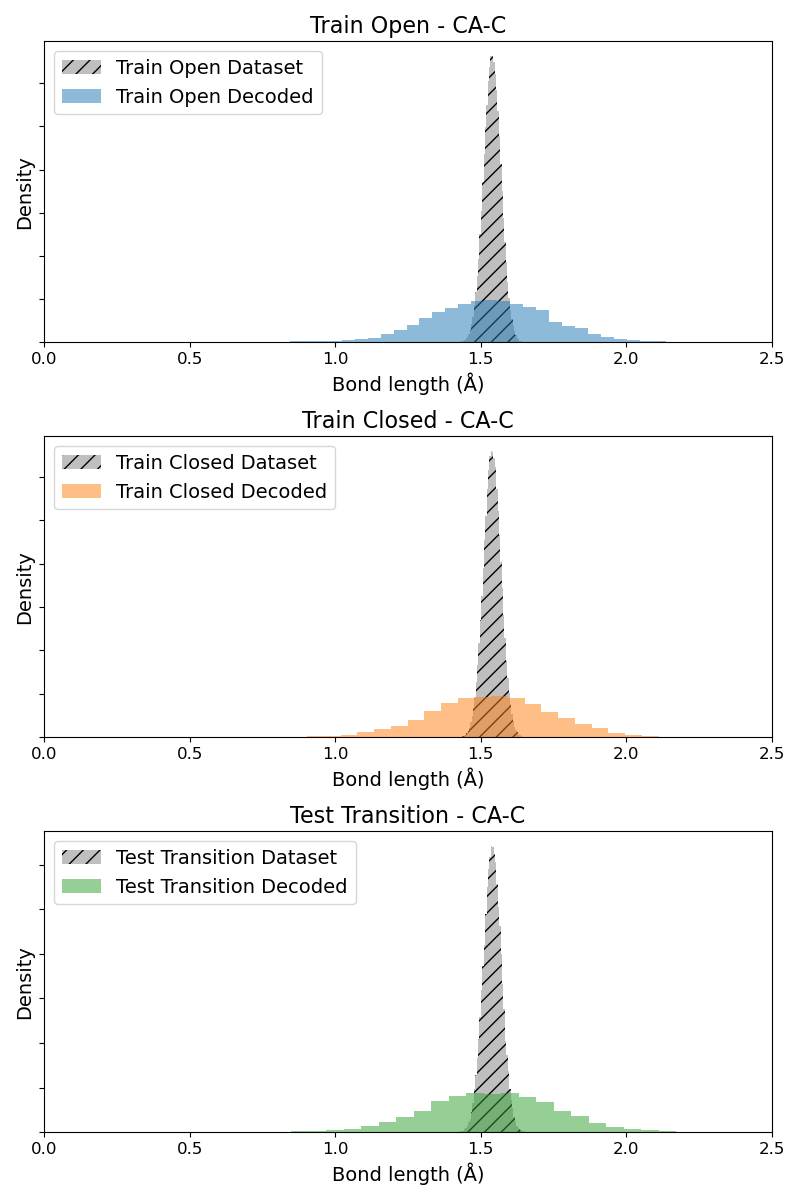

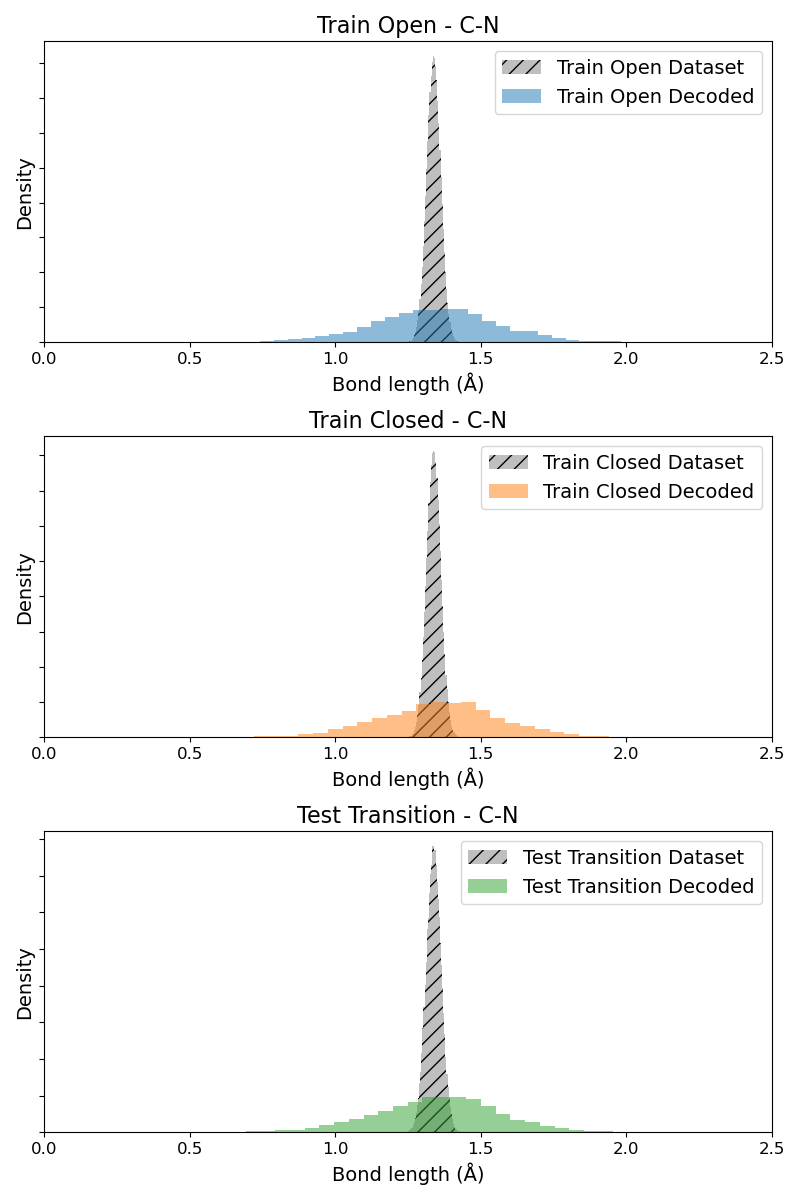

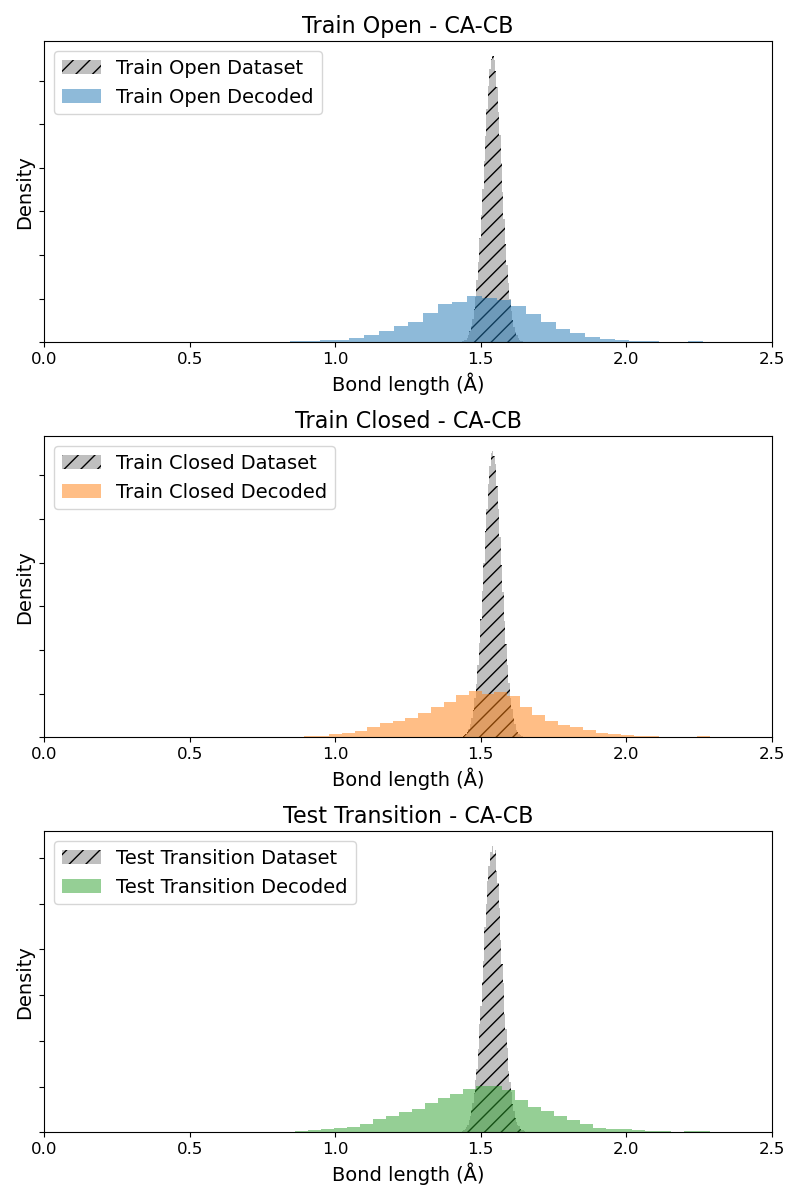

BOND LENGTH DISTRIBUTIONS - latent_dim=11


encoding train_open: 125it [00:00, 283.65it/s]
Decoding train_open: 125it [00:00, 158.20it/s]
encoding train_closed: 125it [00:00, 190.67it/s]
Decoding train_closed: 125it [00:00, 146.43it/s]
encoding test_trans: 13it [00:00, 224.12it/s]
Decoding test_trans: 13it [00:00, 141.31it/s]


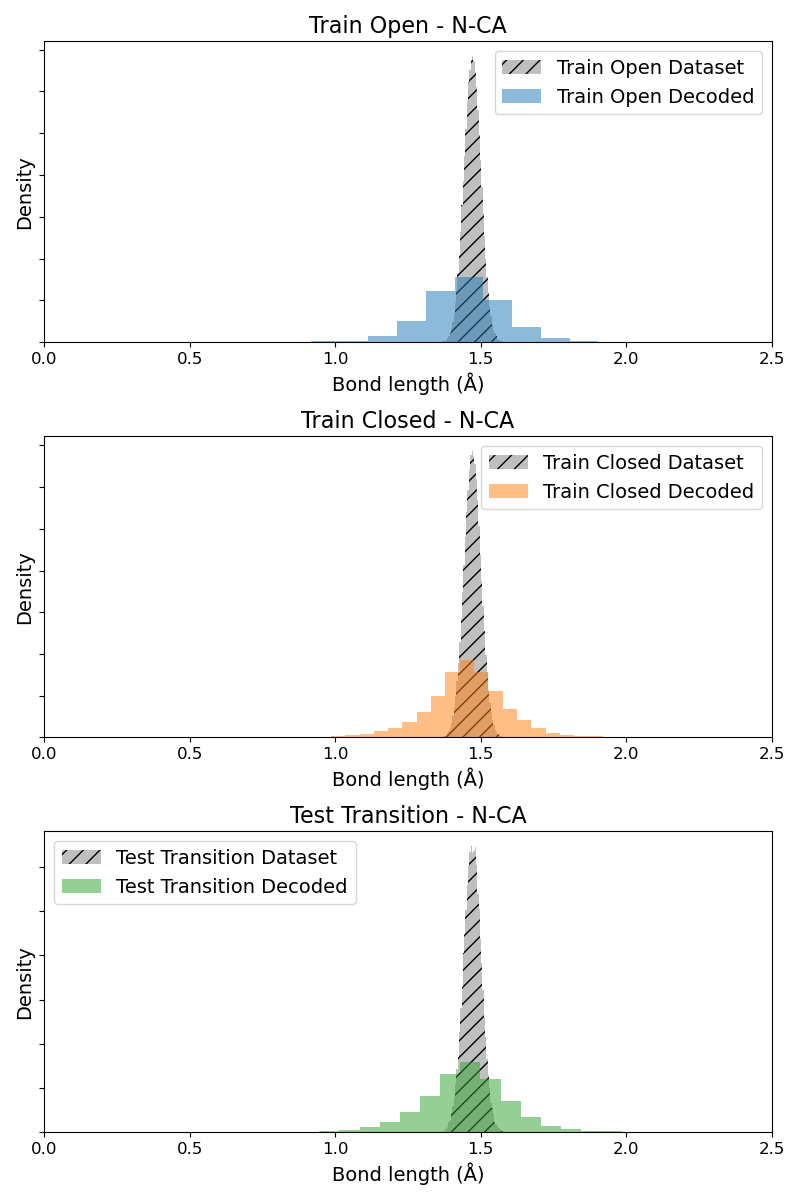

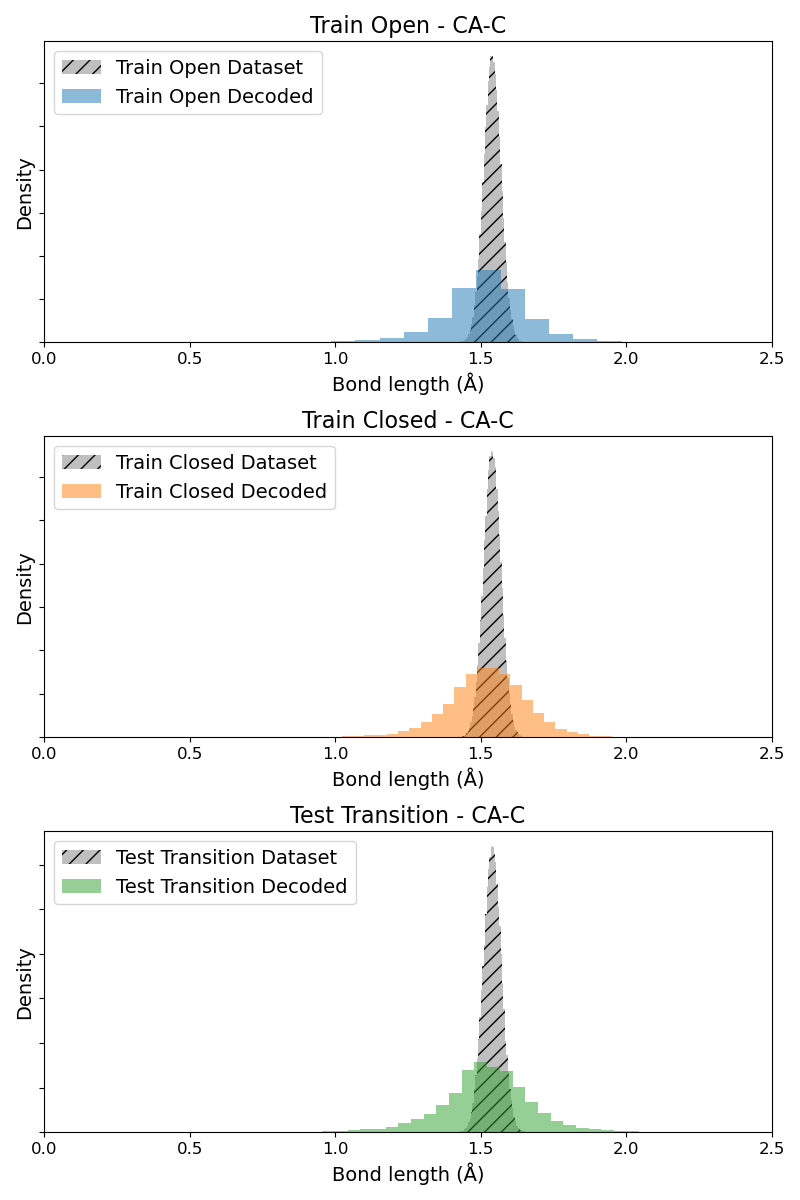

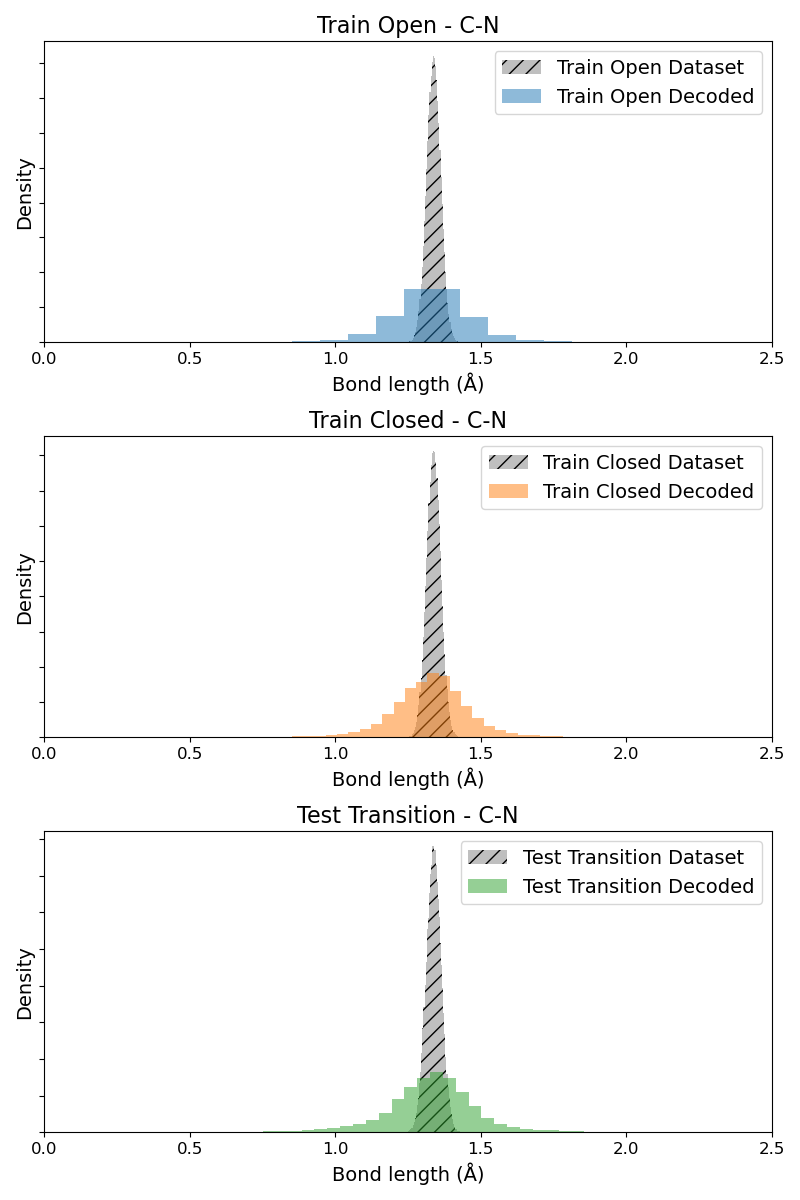

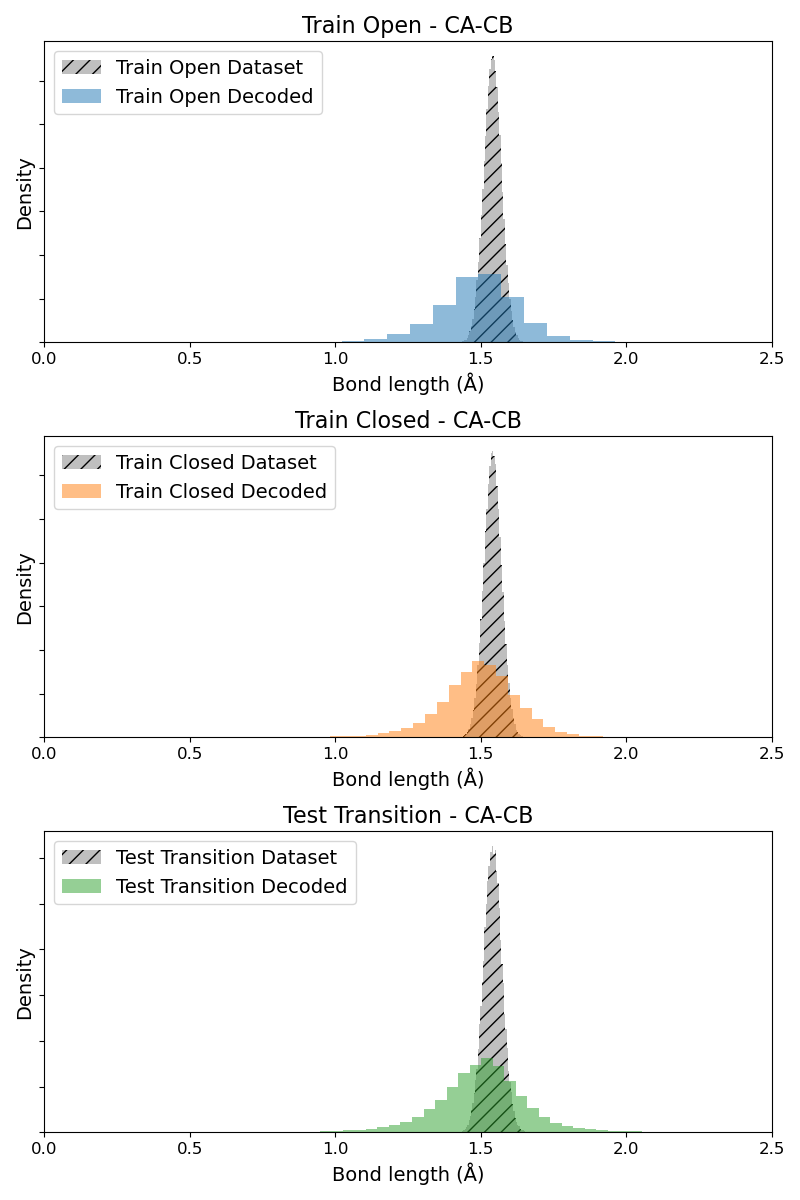

BOND LENGTH DISTRIBUTIONS - latent_dim=13


encoding train_open: 125it [00:00, 157.23it/s]
Decoding train_open: 125it [00:01, 107.12it/s]
encoding train_closed: 125it [00:00, 226.83it/s]
Decoding train_closed: 125it [00:00, 156.40it/s]
encoding test_trans: 13it [00:00, 223.42it/s]
Decoding test_trans: 13it [00:00, 135.95it/s]


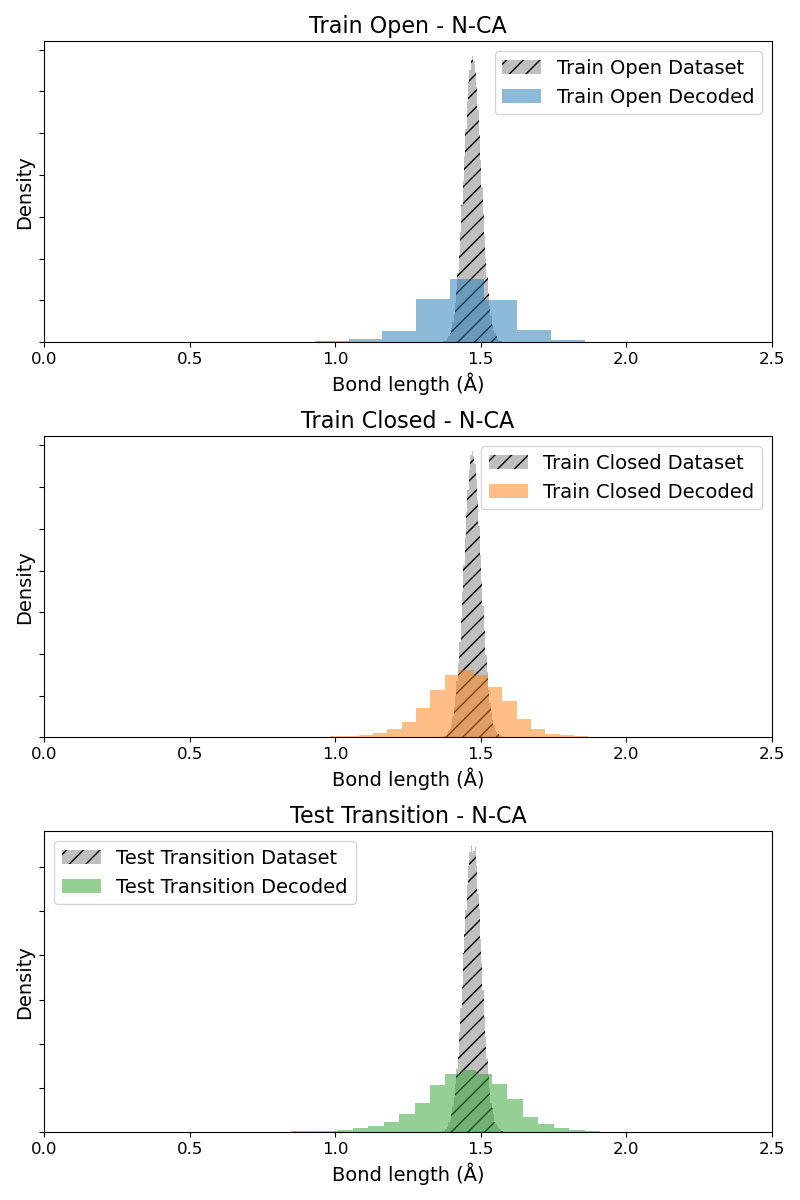

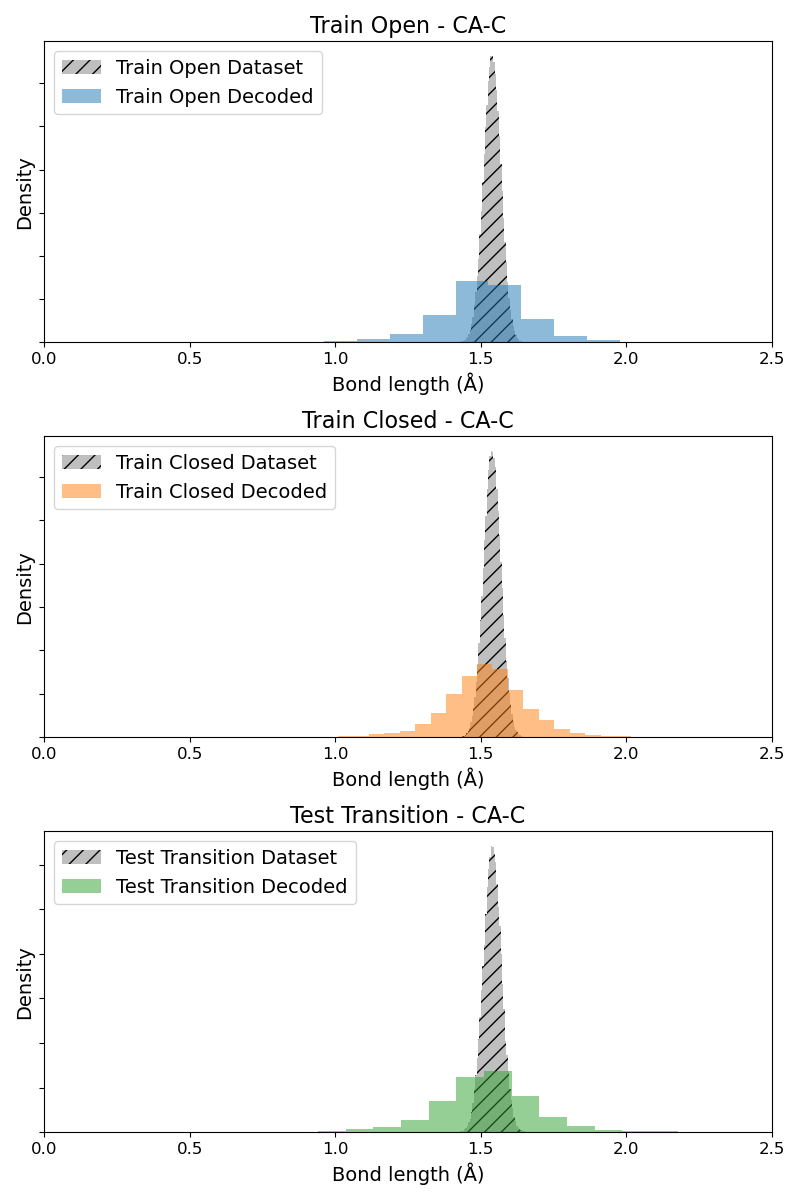

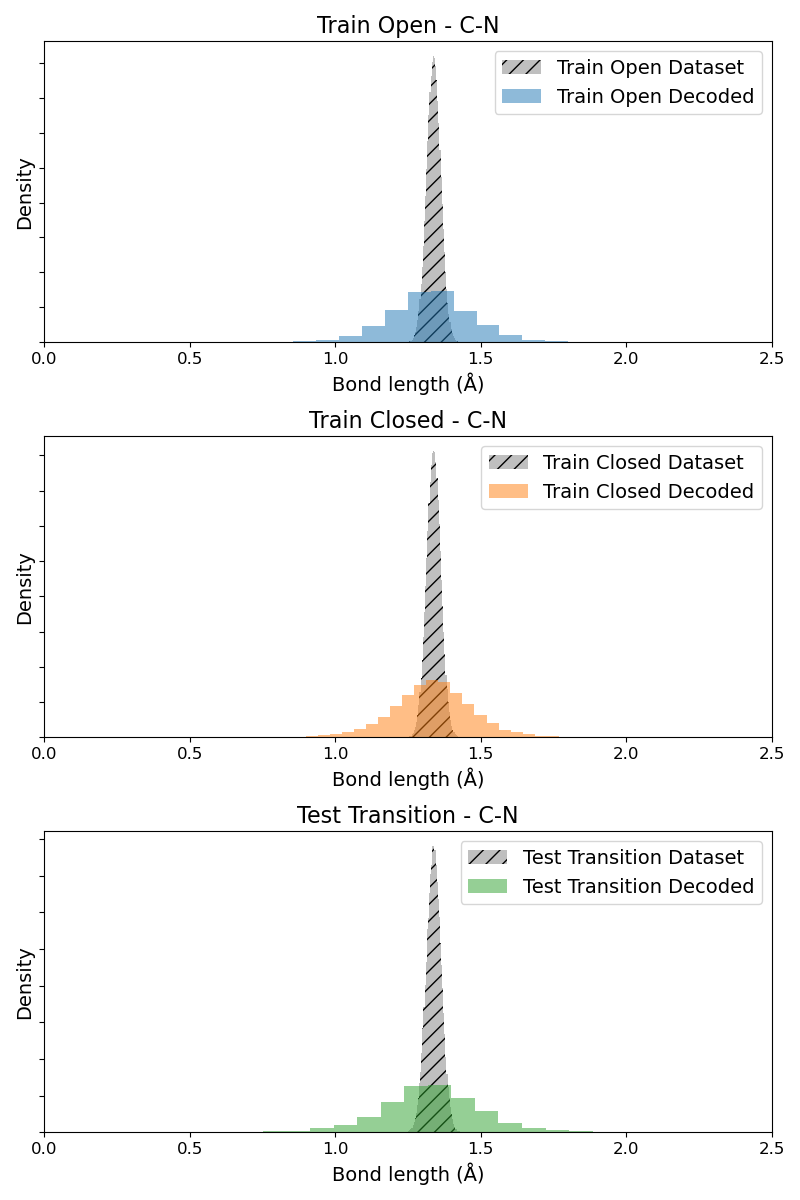

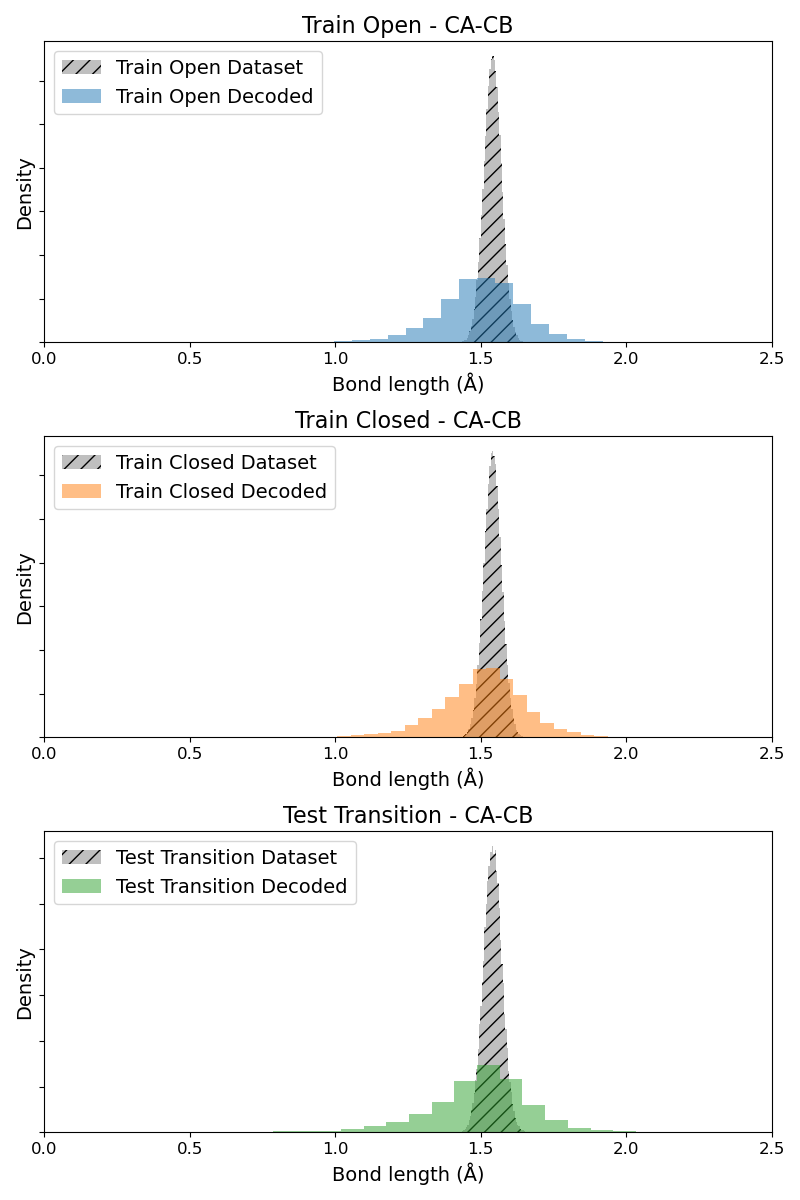

In [ ]:
from molearn.analysis.plot import plot_bondlength_hist

RUN: int = 3

for LATENT_DIM in [2, 11, 13]:

    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={LATENT_DIM}")
    print("=" * 60)
    
    bondlength_train_open = MAs[RUN][LATENT_DIM].get_bondlengths('train_open')
    bondlength_train_closed = MAs[RUN][LATENT_DIM].get_bondlengths('train_closed')
    bondlength_test_trans = MAs[RUN][LATENT_DIM].get_bondlengths('test_trans')

    bondlength_plot_data: list[tuple[str, ...]] = [
        ("train_open", "Train Open", "#1f77b4"),
        ("train_closed", "Train Closed", "#ff7f0e"),
        ("test_trans", "Test Transition", "#2ca02c"),
    ]

    plot_bondlength_hist(
        MAs[RUN][LATENT_DIM],
        plot_data=bondlength_plot_data,
        bins=60,
        dpi=150,
    )

#### Inversion Hist Plot

INVERSION ERRORS - latent_dim=2


encoding train_open: 125it [00:00, 251.80it/s]
Decoding train_open: 125it [00:00, 132.95it/s]
encoding train_closed: 125it [00:00, 226.73it/s]
Decoding train_closed: 125it [00:00, 125.64it/s]
encoding test_trans: 13it [00:00, 246.27it/s]
Decoding test_trans: 13it [00:00, 148.13it/s]


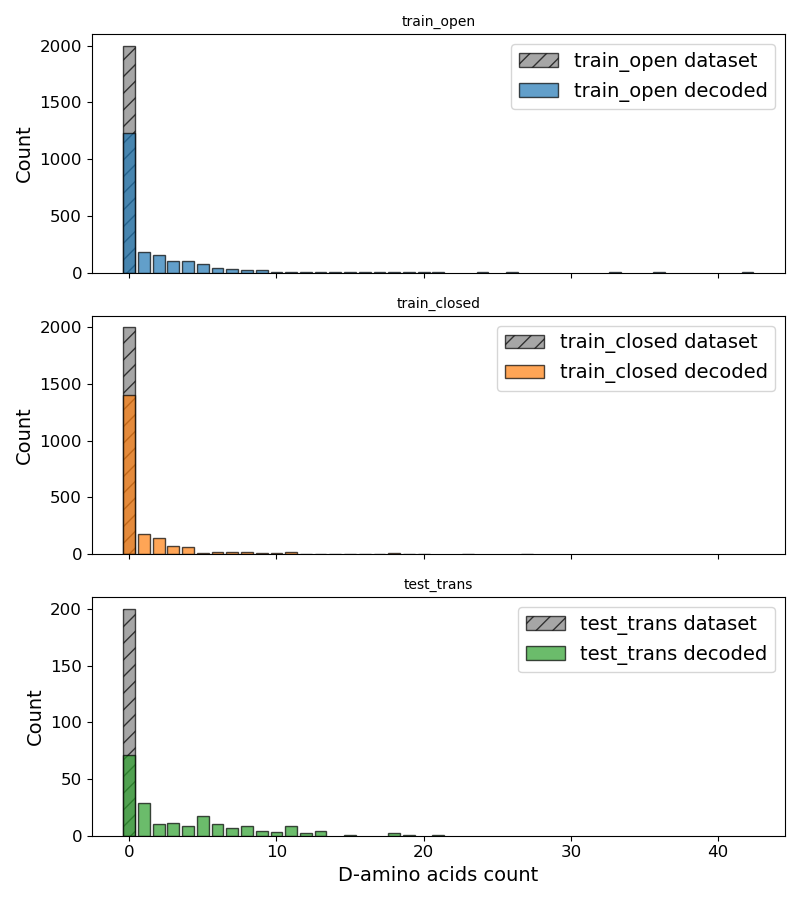

INVERSION ERRORS - latent_dim=11


encoding train_open: 125it [00:00, 249.32it/s]
Decoding train_open: 125it [00:00, 133.47it/s]
encoding train_closed: 125it [00:00, 202.36it/s]
Decoding train_closed: 125it [00:00, 134.41it/s]
encoding test_trans: 13it [00:00, 250.55it/s]
Decoding test_trans: 13it [00:00, 187.25it/s]


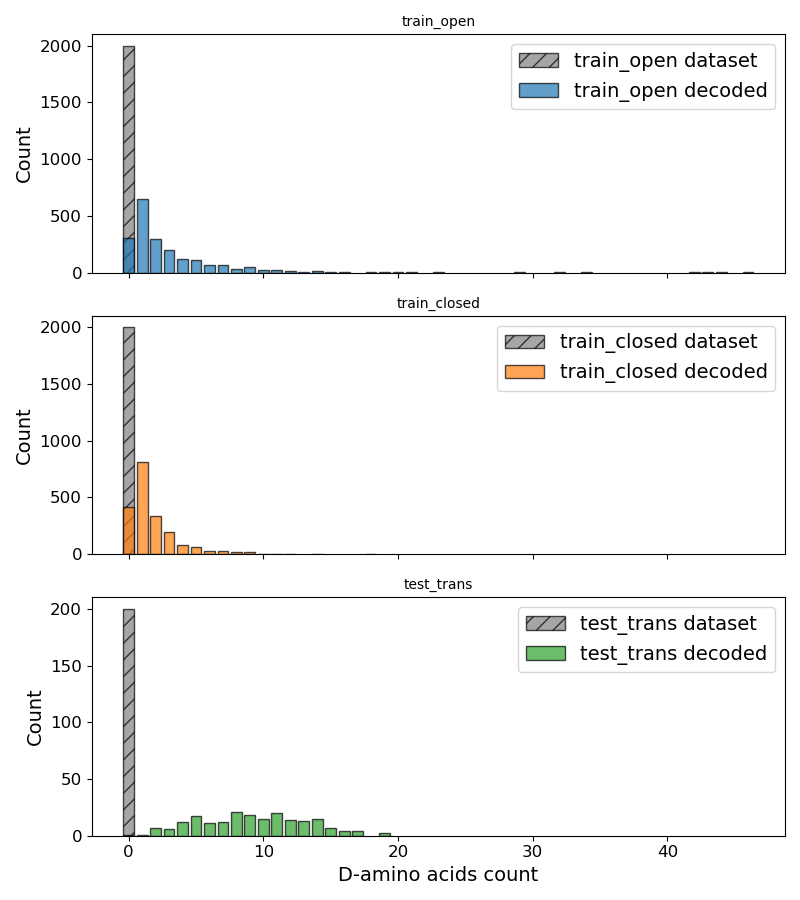

In [ ]:
inversion_plot_data: PlotData = [
    ('train_open', 'train_open', "#1f77b4"),
    ('train_closed', 'train_closed',"#ff7f0e"),
    ('test_trans', 'test_trans', "#2ca02c"),
]

RUN: int = 1

for LATENT_DIM in [2, 11]:
    print("=" * 60)
    print(f"INVERSION ERRORS - latent_dim={LATENT_DIM}")
    print("=" * 60)
    
    plot_inversion_hist(MAs[RUN][LATENT_DIM], 
                        plot_data = inversion_plot_data,
                        )

#### Dope score as a grid (2D only)

encoding train_open: 0it [00:00, ?it/s]

encoding train_open: 125it [00:12, 10.30it/s]
encoding train_closed: 125it [00:07, 16.39it/s]
encoding test_trans: 100it [00:00, 179.68it/s]


Latent grid 'grid' initialised with 20 samples per axis.


Decoding grid: 25it [00:00, 45.21it/s]
Calc Dope: 100%|██████████| 400/400 [00:28<00:00, 14.13it/s]


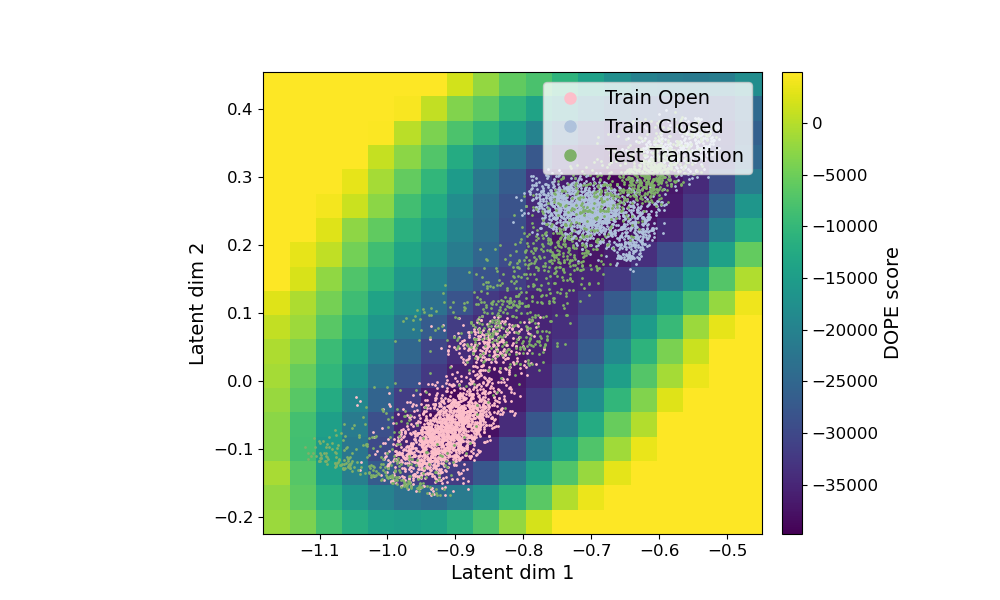

In [ ]:
RUN: int = 1
LATENT_DIM: int = 2


if "grid" not in MAs[RUN][LATENT_DIM]._encoded:
    grid_key: str = MAs[RUN][LATENT_DIM].setup_grid(samples=20)
    print(f"Latent grid '{grid_key}' initialised with {MAs[RUN][LATENT_DIM].n_samples} samples per axis.")
else:
    grid_key: str = "grid"
    print("Re-using previously initialised latent grid.")

refine: bool = True

dope_surface, xvals, yvals = MAs[RUN][LATENT_DIM].scan_dope(refine=refine)
surface_clip: float = np.percentile(dope_surface, 80)

dope_plot_data: list[tuple[str, ...]] = [
    ("train_open", "Train Open", "#FDBFCA", "scatter"),
    ("train_closed", "Train Closed", "#AFC2DC", "scatter"),
    ("test_trans", "Test Transition", "#7FB069", "scatter"),
]

plot_dope_surface(
    MAs[RUN][LATENT_DIM],
    refine=refine,
    truncate_at=surface_clip,
    plot_data=dope_plot_data,
    cmap="viridis",
    bbox_inches="tight",
)

### PCA as a point cloud

Calc Dope: 100%|██████████| 200/200 [00:09<00:00, 20.31it/s]
encoding train_open: 125it [00:00, 285.55it/s]
Calc Dope: 100%|██████████| 200/200 [00:10<00:00, 19.66it/s]
encoding train_closed: 125it [00:00, 252.93it/s]
Calc Dope: 100%|██████████| 160/160 [00:07<00:00, 21.07it/s]
encoding test_trans: 100it [00:00, 290.99it/s]


Latent Dim 2: Total: 100.00%


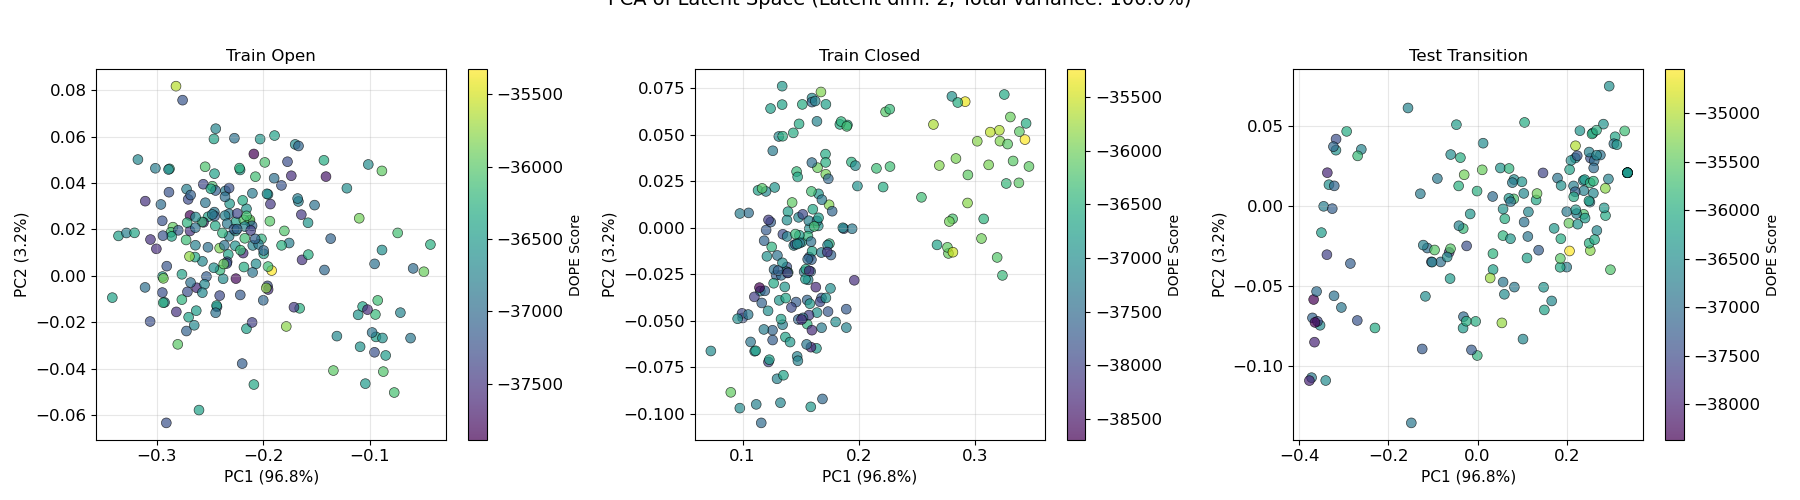

Calc Dope: 100%|██████████| 160/160 [00:07<00:00, 20.47it/s]


Latent Dim 7: Total: 91.60%


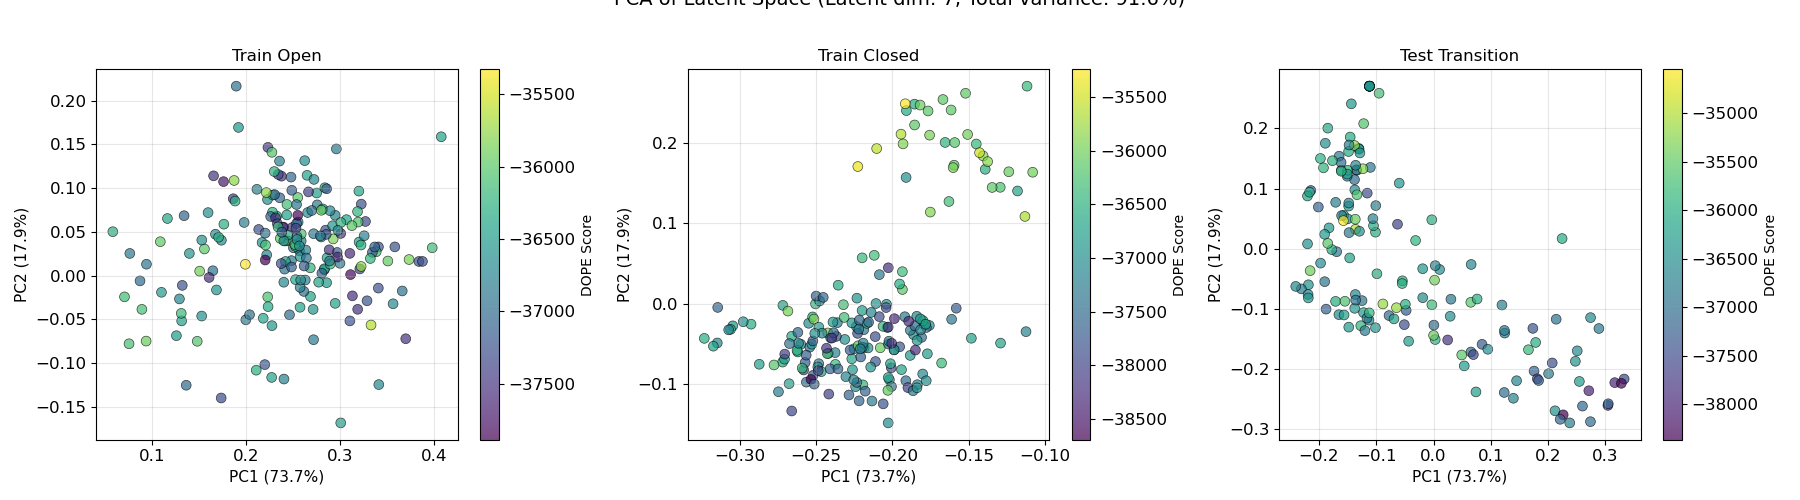

In [ ]:
RUN: int = 1
TARGET_VARS: list[int] = [2, 7]
refine: bool = False
use_partial: bool = True
step: int = 10

dope_scores: dict = {}
pca_results: dict = {}
latent_original_dict: dict = {} 

from sklearn.decomposition import PCA

pcas: dict = {}

keys: list[str] = ['train_open', 'train_closed', 'test_trans']

for LATENT_DIM in TARGET_VARS:

    data: dict = {}
    dope_scores[LATENT_DIM] = {}
    latent_encodings: dict = {}

    # ============================================================
    # getting datasets, dopescores and latent encodings
    # ============================================================

    for key in keys:
        data[key] = MAs[RUN][LATENT_DIM].get_dataset(key, scale=True)[::step]
        dope_scores[LATENT_DIM][key]= MAs[RUN][LATENT_DIM].get_all_dope_score(data[key], refine=refine)
        latent_encodings[key] = MAs[RUN][LATENT_DIM].get_encoded(key)[::step]
    
    # ============================================================
    # Applying PCA
    # ============================================================

    pca = PCA(n_components=2)
    pcas[LATENT_DIM] = pca
    
    latent_all: np.ndarray = np.vstack([latent_encodings[key] for key in keys])

    pca.fit(latent_all)

    var_pc1: float = pca.explained_variance_ratio_[0] * 100
    var_pc2: float = pca.explained_variance_ratio_[1] * 100
    var_total: float = (var_pc1 + var_pc2)
    
    print(f"Latent Dim {LATENT_DIM}: Total: {var_total:.2f}%")

    pca_results[LATENT_DIM] = {
        'train_open': pca.transform(latent_encodings['train_open']),
        'train_closed': pca.transform(latent_encodings['train_closed']),
        'test_trans': pca.transform(latent_encodings['test_trans']),
        'var_pc1': var_pc1,
        'var_pc2': var_pc2,
        'var_total': var_total,
    }
    
    # =============================================================
    # Plotting data 
    # =============================================================

    plot_data: PlotData = [
        ('train_open', 'Train Open', '#FDBFCA'),
        ('train_closed', 'Train Closed', '#AFC2DC'),
        ('test_trans', 'Test Transition', '#7FB069'),
    ]
    
    plot_pca_latent_space(
        pca_results[LATENT_DIM],
        dope_scores[LATENT_DIM],
        plot_data=plot_data,
        latent_dim=LATENT_DIM,
    )

### Decoding data from this new PCA space

Decoding 17x17 = 289 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 289/289 [00:13<00:00, 20.76it/s]


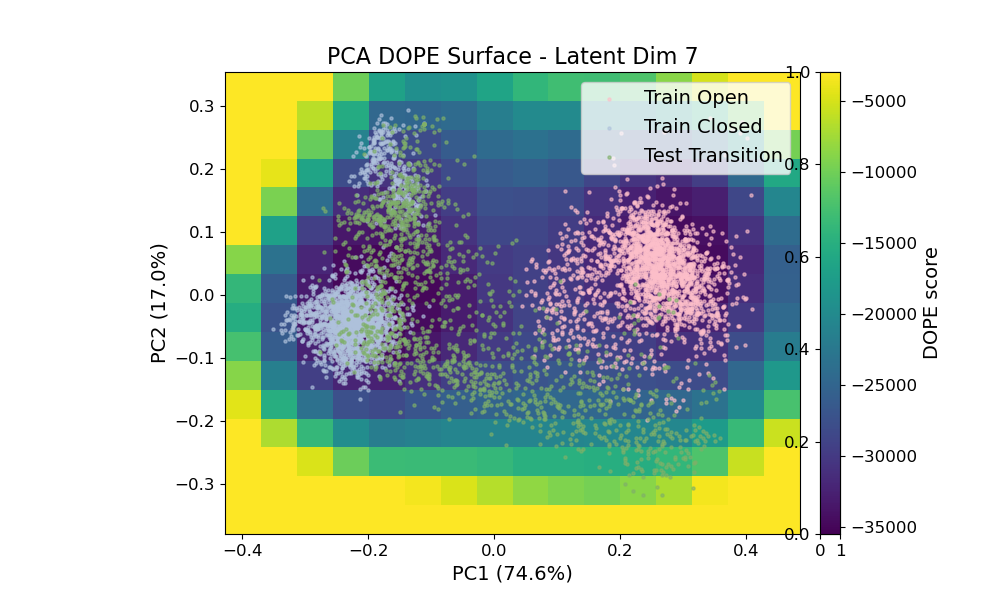

In [ ]:
from matplotlib.colors import Colormap


RUN: int = 1
LATENT_DIM: int = 7
n_samples: int = 17  # Grid resolution
margin: float = 0.1    # 10% margin around data
refine: bool = False

# Get all latent codes and fit PCA
latent_all: np.ndarray = np.vstack([
    MAs[RUN][LATENT_DIM].get_encoded('train_open'),
    MAs[RUN][LATENT_DIM].get_encoded('train_closed'),
    MAs[RUN][LATENT_DIM].get_encoded('test_trans'),
])

pca = PCA(n_components=2)
pca.fit(latent_all)
pca_all: np.ndarray = pca.transform(latent_all)

# Create grid bounds
pc1_min: float = pca_all[:, 0].min()
pc1_max: float = pca_all[:, 0].max()
pc2_min: float = pca_all[:, 1].min()
pc2_max: float = pca_all[:, 1].max()
pc1_range: float = pc1_max - pc1_min
pc2_range: float = pc2_max - pc2_min

pc1_vals: np.ndarray = np.linspace(pc1_min - margin*pc1_range, pc1_max + margin*pc1_range, n_samples)
pc2_vals: np.ndarray = np.linspace(pc2_min - margin*pc2_range, pc2_max + margin*pc2_range, n_samples)

# Create meshgrid in PCA space
pc1_grid: np.ndarray
pc2_grid: np.ndarray
pc1_grid, pc2_grid = np.meshgrid(pc1_vals, pc2_vals)
pca_grid_points: np.ndarray = np.column_stack([pc1_grid.ravel(), pc2_grid.ravel()])

# Inverse transform to full latent space
latent_grid: np.ndarray = pca.inverse_transform(pca_grid_points)

# Decode ALL points at once
print(f"Decoding {n_samples}x{n_samples} = {n_samples**2} grid points...")
with torch.no_grad():
    latent_tensor: Tensor = torch.tensor(latent_grid, dtype=torch.float32)
    decoded_all: np.ndarray = MAs[RUN][LATENT_DIM].network.decode(latent_tensor).numpy()

# Scale back to original coordinates
decoded_scaled: np.ndarray = decoded_all * data_open.std + data_open.mean

# Compute DOPE scores for all structures at once
print("Computing DOPE scores...")
dope_grid: np.ndarray = MAs[RUN][LATENT_DIM].get_all_dope_score(decoded_scaled, refine=refine)


dope_surface: np.ndarray = dope_grid.reshape(n_samples, n_samples)

# Plot
def _latent_edge(values: np.ndarray) -> np.ndarray:
    return np.append(values, (2 * values[-1] - values[-2]))

surface_clip: float = np.percentile(dope_surface, 80)  # type: ignore[assignment]

fig, ax = plt.subplots(figsize=(10, 6))

cmap_obj: Colormap = plt.cm.get_cmap('viridis')
cmap_obj.set_over(cmap_obj(1.0))

mesh = ax.pcolormesh(
    _latent_edge(pc1_vals),
    _latent_edge(pc2_vals),
    dope_surface,
    vmin=dope_surface.min(),
    vmax=surface_clip,
    cmap=cmap_obj,
    shading='auto',
)

ax.set_xlim(pc1_vals.min(), pc1_vals.max())
ax.set_ylim(pc2_vals.min(), pc2_vals.max())
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA DOPE Surface - Latent Dim {LATENT_DIM}')
ax.grid(False)
ax.set_aspect('equal')

# Overlay datasets
pca_open: np.ndarray = pca.transform(MAs[RUN][LATENT_DIM].get_encoded('train_open'))
pca_closed: np.ndarray = pca.transform(MAs[RUN][LATENT_DIM].get_encoded('train_closed'))
pca_test: np.ndarray = pca.transform(MAs[RUN][LATENT_DIM].get_encoded('test_trans'))

ax.scatter(pca_open[:, 0], pca_open[:, 1], c='#FDBFCA', s=5, alpha=0.6, label='Train Open')
ax.scatter(pca_closed[:, 0], pca_closed[:, 1], c='#AFC2DC', s=5, alpha=0.6, label='Train Closed')
ax.scatter(pca_test[:, 0], pca_test[:, 1], c='#7FB069', s=5, alpha=0.6, label='Test Transition')
ax.legend(loc='upper right')

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
]) # type: ignore[assignment]

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
]) # type: ignore[assignment]
cb = fig.colorbar(mesh, cax=cbar_ax)
cb.ax.tick_params(left=False, right=True)
cb.ax.set_ylabel('DOPE score')

plt.show()

### UMAP

Fitting UMAP...
Inverse transforming UMAP grid...
Decoding 10x10 = 100 grid points...
Computing DOPE scores...




































Calc Dope:  17%|█▋        | 621/3600 [03:53<18:40,  2.66it/s]


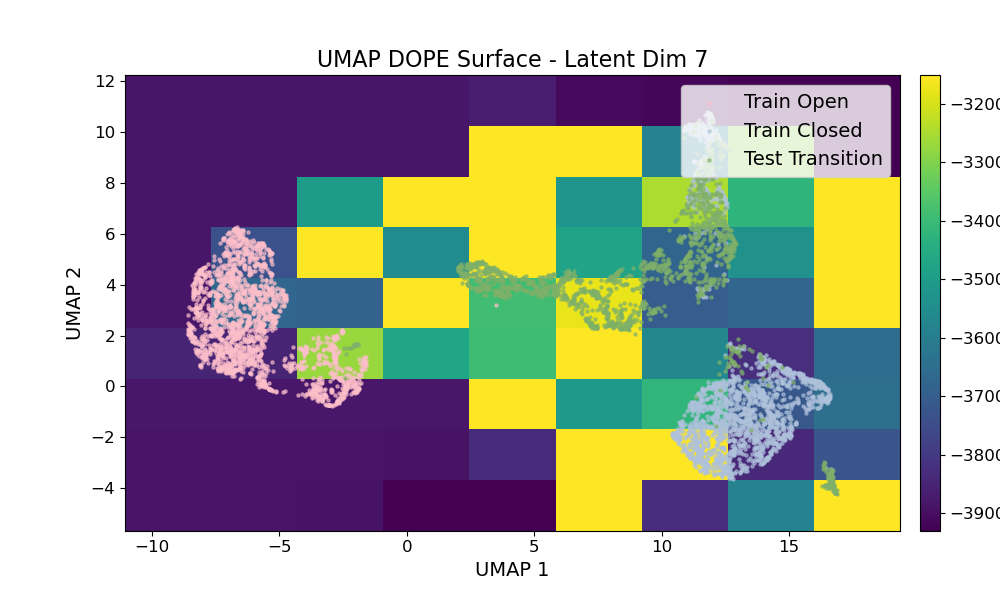

In [ ]:
import umap

RUN: int = 1
LATENT_DIM: int = 7
n_samples: int = 10 # Grid resolution
margin: float = 0.1 # 10% margin around data
refine: bool = True

# Get all latent codes
latent_all: np.ndarray = np.vstack([
    MAs[RUN][LATENT_DIM].get_encoded('train_open'),
    MAs[RUN][LATENT_DIM].get_encoded('train_closed'),
    MAs[RUN][LATENT_DIM].get_encoded('test_trans'),
])

# Fit UMAP
print("Fitting UMAP...")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
embedding: np.ndarray = reducer.fit_transform(latent_all)  # type: ignore[assignment]

# Create grid bounds in UMAP space
u_min: float = embedding[:, 0].min()
u_max: float = embedding[:, 0].max()
v_min: float = embedding[:, 1].min()
v_max: float = embedding[:, 1].max()
u_range: float = u_max - u_min
v_range: float = v_max - v_min

u_vals: np.ndarray = np.linspace(u_min - margin*u_range, u_max + margin*u_range, n_samples)
v_vals: np.ndarray = np.linspace(v_min - margin*v_range, v_max + margin*v_range, n_samples)

u_grid: np.ndarray
v_grid: np.ndarray
u_grid, v_grid = np.meshgrid(u_vals, v_vals)
umap_grid_points: np.ndarray = np.column_stack([u_grid.ravel(), v_grid.ravel()])

print("Inverse transforming UMAP grid...")
latent_grid: np.ndarray = reducer.inverse_transform(umap_grid_points)

print(f"Decoding {n_samples}x{n_samples} = {n_samples**2} grid points...")
with torch.no_grad():
    latent_tensor: Tensor = torch.tensor(latent_grid, dtype=torch.float32)
    decoded_all: np.ndarray = MAs[RUN][LATENT_DIM].network.decode(latent_tensor).numpy()

# Scale back to original coordinates
decoded_scaled: np.ndarray = decoded_all * data_open.std + data_open.mean

print("Computing DOPE scores...")
dope_grid: np.ndarray = MAs[RUN][LATENT_DIM].get_all_dope_score(decoded_scaled, refine=refine)
dope_surface: np.ndarray = dope_grid.reshape(n_samples, n_samples)

# Plot
def _latent_edge(values: np.ndarray) -> np.ndarray:
    return np.append(values, (2 * values[-1] - values[-2]))

surface_clip: float = float(np.percentile(dope_surface, 80))

fig, ax = plt.subplots(figsize=(10, 6))

cmap_obj = plt.cm.get_cmap('viridis')
cmap_obj.set_over(cmap_obj(1.0))

mesh = ax.pcolormesh(
    _latent_edge(u_vals),
    _latent_edge(v_vals),
    dope_surface,
    vmin=dope_surface.min(),
    vmax=surface_clip,
    cmap=cmap_obj,
    shading='auto',
)

ax.set_xlim(u_vals.min(), u_vals.max())
ax.set_ylim(v_vals.min(), v_vals.max())
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f'UMAP DOPE Surface - Latent Dim {LATENT_DIM}')
ax.grid(False)
ax.set_aspect('equal')

# Overlay datasets - transform each dataset through UMAP
umap_open: np.ndarray = reducer.transform(MAs[RUN][LATENT_DIM].get_encoded('train_open')) # type: ignore[reportArgumentType]
umap_closed: np.ndarray = reducer.transform(MAs[RUN][LATENT_DIM].get_encoded('train_closed')) #type : ignore[reportArgumentType]
umap_test: np.ndarray = reducer.transform(MAs[RUN][LATENT_DIM].get_encoded('test_trans')) #type : ignore[reportArgumentType]

ax.scatter(umap_open[:, 0], umap_open[:, 1], c='#FDBFCA', s=5, alpha=0.6, label='Train Open')
ax.scatter(umap_closed[:, 0], umap_closed[:, 1], c='#AFC2DC', s=5, alpha=0.6, label='Train Closed')
ax.scatter(umap_test[:, 0], umap_test[:, 1], c='#7FB069', s=5, alpha=0.6, label='Test Transition')
ax.legend(loc='upper right')

# Add colorbar
cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
]) # type: ignore[reportArgumentType]

cb = fig.colorbar(mesh, cax=cbar_ax)
cb.ax.tick_params(left=False, right=True)
cb.ax.set_ylabel('DOPE score')

plt.show()

### 3D PCA Plotly

In [ ]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

LATENT_DIM: int = 3

# Get latent encodings
latent_open: np.ndarray = MAs[LATENT_DIM].get_encoded('train_open')
latent_closed: np.ndarray = MAs[LATENT_DIM].get_encoded('train_closed')
latent_test: np.ndarray = MAs[LATENT_DIM].get_encoded('test_trans')
latent_all: np.ndarray = np.vstack([latent_open, latent_closed, latent_test])

# Subsample for performance (adjust step as needed)
step: int = 5
latent_open_sub: np.ndarray = latent_open[::step]
latent_closed_sub: np.ndarray = latent_closed[::step]
latent_test_sub: np.ndarray = latent_test[::step]

# Fit PCA
pca = PCA(n_components=2)
pca.fit(latent_all)

mean: np.ndarray = pca.mean_
pc1: np.ndarray = pca.components_[0]
pc2: np.ndarray = pca.components_[1]

# Create PCA plane mesh
grid_range: int = 3
u: np.ndarray = np.linspace(-grid_range, grid_range, 15)
v: np.ndarray = np.linspace(-grid_range, grid_range, 15)
U: np.ndarray
V: np.ndarray
U, V = np.meshgrid(u, v)

plane_x: np.ndarray = mean[0] + U * pc1[0] + V * pc2[0]
plane_y: np.ndarray = mean[1] + U * pc1[1] + V * pc2[1]
plane_z: np.ndarray = mean[2] + U * pc1[2] + V * pc2[2]

# Create figure
fig = go.Figure()

# Add data points (subsampled)
fig.add_trace(go.Scatter3d(
    x=latent_open_sub[:, 0], y=latent_open_sub[:, 1], z=latent_open_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#FDBFCA', opacity=0.7),
    name='Train Open'
))
fig.add_trace(go.Scatter3d(
    x=latent_closed_sub[:, 0], y=latent_closed_sub[:, 1], z=latent_closed_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#AFC2DC', opacity=0.7),
    name='Train Closed'
))
fig.add_trace(go.Scatter3d(
    x=latent_test_sub[:, 0], y=latent_test_sub[:, 1], z=latent_test_sub[:, 2],
    mode='markers', marker=dict(size=2, color='#7FB069', opacity=0.7),
    name='Test Transition'
))

# Add PCA plane
fig.add_trace(go.Surface(
    x=plane_x, y=plane_y, z=plane_z,
    opacity=0.4, colorscale=[[0, 'royalblue'], [1, 'royalblue']], 
    showscale=False, name='PCA Plane'
))

# Add PC vectors as lines
arrow_scale: int = 2
fig.add_trace(go.Scatter3d(
    x=[mean[0], mean[0] + pc1[0]*arrow_scale],
    y=[mean[1], mean[1] + pc1[1]*arrow_scale],
    z=[mean[2], mean[2] + pc1[2]*arrow_scale],
    mode='lines', line=dict(color='red', width=6),
    name=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
))
fig.add_trace(go.Scatter3d(
    x=[mean[0], mean[0] + pc2[0]*arrow_scale],
    y=[mean[1], mean[1] + pc2[1]*arrow_scale],
    z=[mean[2], mean[2] + pc2[2]*arrow_scale],
    mode='lines', line=dict(color='orange', width=6),
    name=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
))

fig.update_layout(
    title=f'3D Latent Space with PCA Plane<br>Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%',
    scene=dict(
        xaxis_title='Latent 1',
        yaxis_title='Latent 2',
        zaxis_title='Latent 3',
        xaxis=dict(range=[-1.5, 1.5]),
        yaxis=dict(range=[-1.5, 1.5]),
        zaxis=dict(range=[-1.5, 1.5]),
        aspectmode='cube'
    ),
    width=800, height=700,
    legend=dict(x=0.02, y=0.98),
)

fig.show()

### Autoencoder